In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/nikitagupta1812/economic-dataset/economic_index_dataset_large.csv


In [2]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline


In [3]:
df = pd.read_csv('/kaggle/input/datasets/nikitagupta1812/economic-dataset/economic_index_dataset_large.csv')
df

,year,month,interest_rate,unemployment_rate,index_price
0,2015,1,2.44,5.64,719
1,2015,2,2.62,6.94,671
2,2015,3,2.89,4.61,885
3,2015,4,3.27,6.39,833
4,2015,5,2.04,5.35,712
5,2015,6,3.32,5.50,828
6,2015,7,2.05,6.86,654
7,2015,8,2.66,4.90,830
8,2015,9,1.77,6.29,680
9,2015,10,2.41,6.49,738


In [4]:
df.head()

,year,month,interest_rate,unemployment_rate,index_price
0,2015,1,2.44,5.64,719
1,2015,2,2.62,6.94,671
2,2015,3,2.89,4.61,885
3,2015,4,3.27,6.39,833
4,2015,5,2.04,5.35,712


In [5]:
df.isnull().sum()

year                 0
month                0
interest_rate        0
unemployment_rate    0
index_price          0
dtype: int64

In [6]:
df.isnull().mean()

year                 0.0
month                0.0
interest_rate        0.0
unemployment_rate    0.0
index_price          0.0
dtype: float64

## Drop Unnecessary column

In [7]:
df.drop(columns=['year','month'],axis=1,inplace=True)


In [8]:
df.head()

,interest_rate,unemployment_rate,index_price
0,2.44,5.64,719
1,2.62,6.94,671
2,2.89,4.61,885
3,3.27,6.39,833
4,2.04,5.35,712


In [9]:
## Check Null Values 
df.isnull().sum()

interest_rate        0
unemployment_rate    0
index_price          0
dtype: int64

## Visualizations

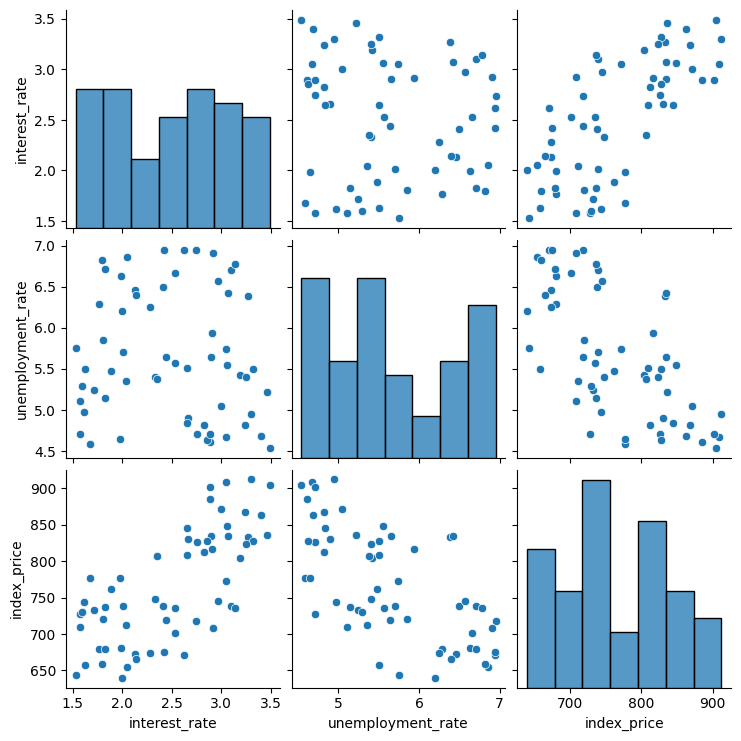

In [10]:
import seaborn as sns
sns.pairplot(df)

In [11]:
df.corr()

,interest_rate,unemployment_rate,index_price
interest_rate,1.000000,-0.092580,0.712337
unemployment_rate,-0.092580,1.000000,-0.660595
index_price,0.712337,-0.660595,1.000000


## Visualize the DataPoints More Closely

Text(0, 0.5, 'Unemployement Rate')

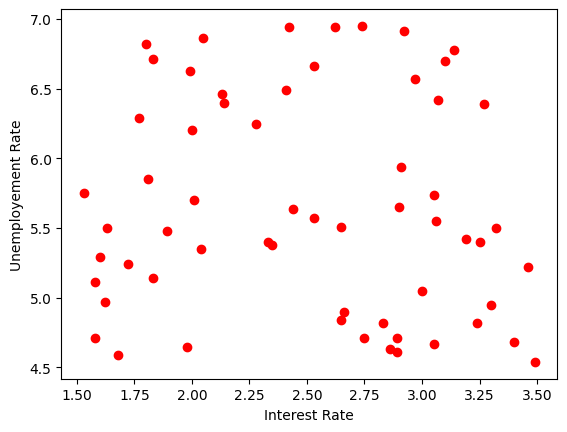

In [12]:
plt.scatter(df['interest_rate'],df['unemployment_rate'],color='red')
plt.xlabel("Interest Rate")
plt.ylabel("Unemployement Rate")

## INDEPENDENT FEATURES AND DEPENDENT FEATURE

In [13]:
X = df[['interest_rate','unemployment_rate']]
y = df['index_price']

In [14]:
X

,interest_rate,unemployment_rate
0,2.44,5.64
1,2.62,6.94
2,2.89,4.61
3,3.27,6.39
4,2.04,5.35
5,3.32,5.50
6,2.05,6.86
7,2.66,4.90
8,1.77,6.29
9,2.41,6.49


In [15]:
y

0     719
1     671
2     885
3     833
4     712
5     828
6     654
7     830
8     680
9     738
10    718
11    733
12    834
13    739
14    658
15    739
16    736
17    745
18    905
19    675
20    681
21    640
22    728
23    835
24    804
25    863
26    826
27    659
28    730
29    709
30    836
31    912
32    868
33    643
34    848
35    744
36    720
37    817
38    909
39    827
40    679
41    735
42    708
43    809
44    737
45    748
46    871
47    807
48    777
49    824
50    845
51    772
52    901
53    673
54    762
55    674
56    701
57    812
58    777
59    665
Name: index_price, dtype: int64

## Train Test Split

In [16]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=0)

<Axes: xlabel='interest_rate', ylabel='index_price'>

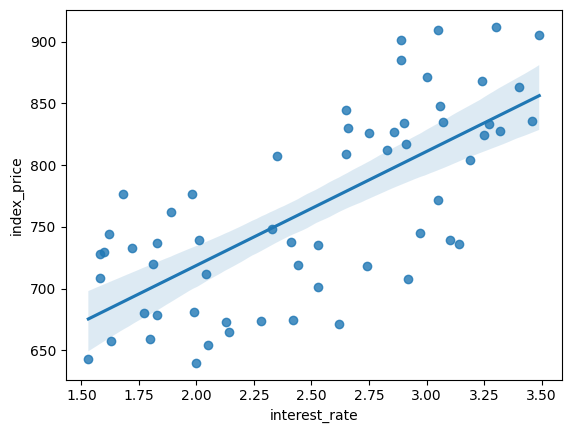

In [17]:
sns.regplot(x=df['interest_rate'], y=df['index_price'])

<Axes: xlabel='unemployment_rate', ylabel='index_price'>

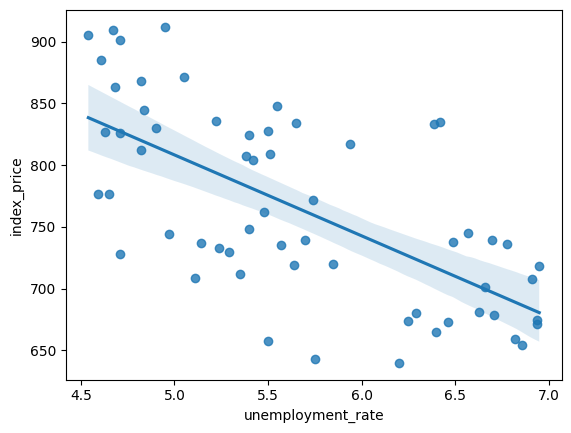

In [18]:
sns.regplot(x=df['unemployment_rate'], y=df['index_price'])

## Standard Scaling

In [19]:
from sklearn.preprocessing import StandardScaler


In [20]:
scaler = StandardScaler()
X_train= scaler.fit_transform(X_train)
X_test=  scaler.fit_transform(X_test)

In [21]:
X_test

array([[ 1.11717036, -0.90890858],
       [-1.03159986, -0.57993007],
       [-0.04278525,  1.22945174],
       [-1.06963119, -0.17503344],
       [-0.84144321, -0.23829854],
       [ 1.38338968, -1.03543877],
       [ 1.70665599,  0.15394507],
       [-0.3470359 , -0.98482669],
       [-0.63227088,  1.62169535],
       [-1.10766252, -0.90890858],
       [-0.2329419 , -0.09911532],
       [ 1.09815469,  1.92536782]])

In [22]:
X_test

array([[ 1.11717036, -0.90890858],
       [-1.03159986, -0.57993007],
       [-0.04278525,  1.22945174],
       [-1.06963119, -0.17503344],
       [-0.84144321, -0.23829854],
       [ 1.38338968, -1.03543877],
       [ 1.70665599,  0.15394507],
       [-0.3470359 , -0.98482669],
       [-0.63227088,  1.62169535],
       [-1.10766252, -0.90890858],
       [-0.2329419 , -0.09911532],
       [ 1.09815469,  1.92536782]])

In [23]:
from sklearn.linear_model import LinearRegression 
regression = LinearRegression()

In [24]:
regression.fit(X_train,y_train)

LinearRegression()

## Import Cross Validation

In [25]:
from sklearn.model_selection import cross_val_score
validation_score= cross_val_score(regression,X_train,y_train,scoring='neg_mean_squared_error',
                                 cv=3)

In [26]:
np.mean(validation_score)

np.float64(-999.8602017970587)

## Prediction 

In [27]:
y_pred = regression.predict(X_test)


In [28]:
y_pred

array([863.42043641, 744.19731245, 710.15754889, 723.99270912,
       737.93805508, 882.0804317 , 843.84462794, 795.78628434,
       663.75762731, 755.42128581, 761.1655623 , 733.98811866])

## Performance Metrics 

In [29]:
from sklearn.metrics import mean_absolute_error,mean_squared_error

In [30]:
mse = mean_squared_error(y_test,y_pred)
mae = mean_absolute_error(y_test,y_pred)
rmse= np.sqrt(mse)


In [31]:
print(mae)
print(mse)
print(rmse)

18.949933989269862
627.9874097164505
25.059676967519962


In [32]:
from sklearn.metrics import r2_score
score = r2_score(y_test,y_pred)
print(score)
## Display Adjusted R-Squared
print(1-(1-score)*len(y_test)/(len(y_test)-X_test.shape[1]-1))

0.8496086190078997
0.7994781586771996


## ASSUMPTIONS

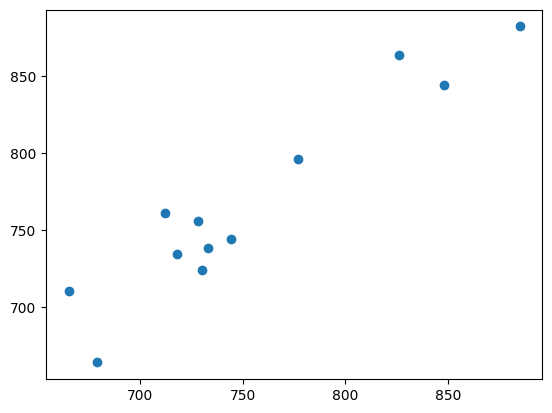

In [33]:
plt.scatter(y_test,y_pred)

In [34]:
residuals = y_test-y_pred
print(residuals)

26   -37.420436
35    -0.197312
59   -45.157549
28     6.007291
11    -4.938055
2      2.919568
34     4.155372
58   -18.786284
40    15.242373
22   -27.421286
4    -49.165562
10   -15.988119
Name: index_price, dtype: float64


/tmp/ipykernel_16/2612966733.py:2: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(residuals,kde=True)


<Axes: xlabel='index_price', ylabel='Density'>

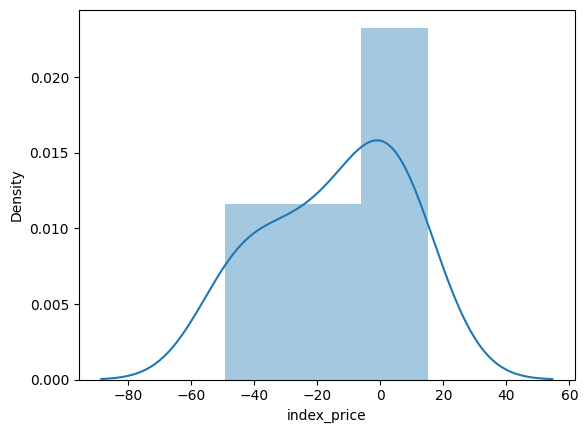

In [35]:
## Plot this Residuals
sns.distplot(residuals,kde=True)

it is ideally perfect ideal (not so good)

## Scatter Plot with respect to predictions and residuals


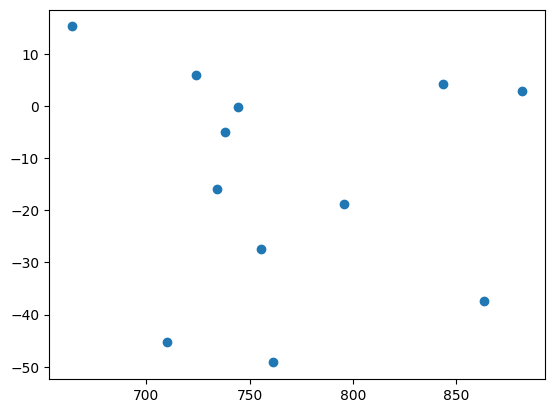

In [36]:
plt.scatter(y_pred,residuals)

## OLS Linear Regression

In [37]:
import statsmodels.api as sm
model = sm.OLS(y_train,X_train).fit()

In [38]:
model.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                                 OLS Regression Results                                
=======================================================================================
Dep. Variable:            index_price   R-squared (uncentered):                   0.009
Model:                            OLS   Adj. R-squared (uncentered):             -0.034
Method:                 Least Squares   F-statistic:                             0.2066
Date:                Sat, 11 Apr 2026   Prob (F-statistic):                       0.814
Time:                        17:00:54   Log-Likelihood:                         -387.05
No. Observations:                  48   AIC:                                      778.1
Df Residuals:                      46   BIC:                                      781.8
Df Model:                           2                                                  
Covariance Type:            nonrobust                                                  
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
x1            48.5426    115.719      0.419      0.677    -184.388     281.473
x2           -45.3411    115.719     -0.392      0.697    -278.271     187.589
==============================================================================
Omnibus:                        6.138   Durbin-Watson:                   0.003
Prob(Omnibus):                  0.046   Jarque-Bera (JB):                2.593
Skew:                           0.248   Prob(JB):                        0.274
Kurtosis:                       1.975   Cond. No.                         1.23
==============================================================================

Notes:
[1] R² is computed without centering (uncentered) since the model does not contain a constant.
[2] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

In [39]:
print(regression.coef_)

[ 48.54259009 -45.34111363]
